# 03 · A/B test design: proactive delay notification

`02_late_delivery_stats.ipynb` showed late orders get a 1-star review 8x as often as on-time ones. Lateness
itself can't be randomized, so the experiment tests a **mitigation** (insight memo, recommendation #1).

| | |
|---|---|
| **Hypothesis** | Proactively messaging customers whose order is predicted to be late (new date + small voucher) lowers the 1-star rate among late orders. |
| **Unit of randomization** | `customer_unique_id`, 50/50, sticky (a customer's later orders stay in the same arm). Avoids one person seeing both experiences. |
| **Eligible** | Orders the delay model flags as at-risk. **Analysis population**: orders that actually arrive late and get a review. |
| **Primary metric** | 1-star rate among late, reviewed orders (control baseline ≈ 54%). |
| **Secondary** | Mean review score among late orders; 1-star rate among all flagged orders. |
| **Guardrails** | Voucher cost per order (budget cap), refund / cancellation rate, on-time orders' review score (false-positive flags must not annoy). |
| **Test** | Two-sided two-proportion z-test, α = 0.05, power = 0.80. |

Sections: 1 baseline + traffic · 2 power analysis + MDE-vs-duration · 3 recommendation · 4 A/A simulation ·
5 sample-ratio mismatch · 6 peeking.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "PLAN.md").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from scripts import db
from scripts.plot_style import BLUE, GREY, INK_2, apply_style
from scripts.stats_helpers import mde_table, n_per_arm, simulate_aa, srm_pvalue

apply_style()
pd.set_option("display.width", 140, "display.float_format", "{:,.4f}".format)
ALPHA, POWER, SEED = 0.05, 0.80, 42

## 1. Baseline and eligible traffic

Baseline = 1-star rate among late, reviewed orders. Traffic = late, reviewed orders per purchase month in
**Jan–Aug 2018** (the most recent complete months in the trend window): the volume the test would see at
today's run-rate.

In [2]:
monthly = db.read_sql("""
    select
        date_trunc('month', purchased_at)::date                          as month,
        count(*) filter (where is_late)                                   as late_orders,
        count(*) filter (where is_late and review_score is not null)      as late_reviewed,
        count(*) filter (where is_late and review_score = 1)              as late_one_star,
        count(*)                                                          as delivered_dated
    from marts.fact_orders
    where is_late is not null
      and purchased_at >= '2018-01-01' and purchased_at < '2018-09-01'
    group by 1
    order by 1
""")
monthly["late_share"] = monthly["late_orders"] / monthly["delivered_dated"]
monthly["one_star_rate_late"] = monthly["late_one_star"] / monthly["late_reviewed"]
monthly

,month,late_orders,late_reviewed,late_one_star,delivered_dated,late_share,one_star_rate_late
0,2018-01-01,403,396,241,7069,0.0570,0.6086
1,2018-02-01,926,912,585,6555,0.1413,0.6414
2,2018-03-01,1328,1296,769,7003,0.1896,0.5934
3,2018-04-01,306,297,158,6798,0.0450,0.5320
4,2018-05-01,443,437,168,6749,0.0656,0.3844
5,2018-06-01,71,71,37,6096,0.0116,0.5211
6,2018-07-01,208,200,86,6156,0.0338,0.4300
7,2018-08-01,393,385,130,6351,0.0619,0.3377


In [3]:
overall = db.read_sql("""
    select avg(is_one_star::int) as p
    from marts.fact_orders
    where is_late and review_score is not null
""")["p"].iloc[0]
p_2018 = monthly["late_one_star"].sum() / monthly["late_reviewed"].sum()
runrate = monthly["late_reviewed"].mean()
print(f"Baseline 1-star rate among late orders: all data {overall:.1%}, Jan-Aug 2018 {p_2018:.1%}")
print(f"Late, reviewed orders per month (Jan-Aug 2018): mean {runrate:,.0f}, "
      f"min {monthly['late_reviewed'].min():,} ({monthly.loc[monthly['late_reviewed'].idxmin(), 'month']:%b}), "
      f"max {monthly['late_reviewed'].max():,} ({monthly.loc[monthly['late_reviewed'].idxmax(), 'month']:%b})")
P0 = 0.54  # planning baseline (rounded all-data rate; the 2018 rate is within 1 pp)

Baseline 1-star rate among late orders: all data 53.8%, Jan-Aug 2018 54.4%
Late, reviewed orders per month (Jan-Aug 2018): mean 499, min 71 (Jun), max 1,296 (Mar)


**Traffic is lumpy.** Late volume swings by more than an order of magnitude month to month (Feb–Mar 2018
carry carrier backlogs; June is nearly clean). Durations below use the mean run-rate; in a calm month the
test fills much more slowly, which is the main schedule risk.

## 2. Power analysis

5-pp minimum detectable effect (54% → 49%, about a 9% relative cut):

`NormalIndPower().solve_power(effect_size=proportion_effectsize(0.54, 0.49), alpha=0.05, power=0.8)`

`nobs1` is the size of **each** arm. Cross-check: Cohen's h-based formula n = 2(z₁₋α/₂ + z₁₋β)² / h²
and the classic pooled-variance formula for two proportions give the same answer.

In [4]:
h = proportion_effectsize(P0, 0.49)
n_sm = NormalIndPower().solve_power(effect_size=h, alpha=ALPHA, power=POWER, ratio=1.0)
za, zb = norm.ppf(1 - ALPHA / 2), norm.ppf(POWER)
n_cohen = 2 * (za + zb) ** 2 / h**2
pbar = (P0 + 0.49) / 2
n_classic = ((za * np.sqrt(2 * pbar * (1 - pbar)) + zb * np.sqrt(P0 * (1 - P0) + 0.49 * 0.51)) / 0.05) ** 2
print(f"Cohen's h = {h:.4f}")
print(f"n per arm: statsmodels {n_sm:,.1f} | Cohen formula {n_cohen:,.1f} | pooled-variance formula {n_classic:,.1f}")
N_5PP = n_per_arm(P0, 0.49)
print(f"=> {N_5PP:,} late, reviewed orders per arm, {2 * N_5PP:,} in total, "
      f"≈ {2 * N_5PP / runrate:.1f} months at {runrate:,.0f}/month")

Cohen's h = 0.1001
n per arm: statsmodels 1,567.0 | Cohen formula 1,567.1 | pooled-variance formula 1,567.2
=> 1,568 late, reviewed orders per arm, 3,136 in total, ≈ 6.3 months at 499/month


### MDE vs duration

The smaller the effect we insist on detecting, the longer the test. Absolute MDE in percentage points off the
54% baseline; months = total sample / mean monthly late, reviewed orders.

In [5]:
table = mde_table(P0, [3, 4, 5, 6, 7, 8, 10], units_per_month=runrate, alpha=ALPHA, power=POWER)
table.style.format({"p_control": "{:.0%}", "p_treatment": "{:.0%}", "relative_mde": "{:.0%}",
                    "n_per_arm": "{:,}", "n_total": "{:,}", "months": "{:.1f}"}).hide(axis="index")

mde_pp,p_control,p_treatment,relative_mde,n_per_arm,n_total,months
3,54%,51%,6%,"4,349","8,698",17.4
4,54%,50%,7%,"2,448","4,896",9.8
5,54%,49%,9%,"1,568","3,136",6.3
6,54%,48%,11%,"1,089","2,178",4.4
7,54%,47%,13%,800,"1,600",3.2
8,54%,46%,15%,612,"1,224",2.5
10,54%,44%,19%,391,782,1.6


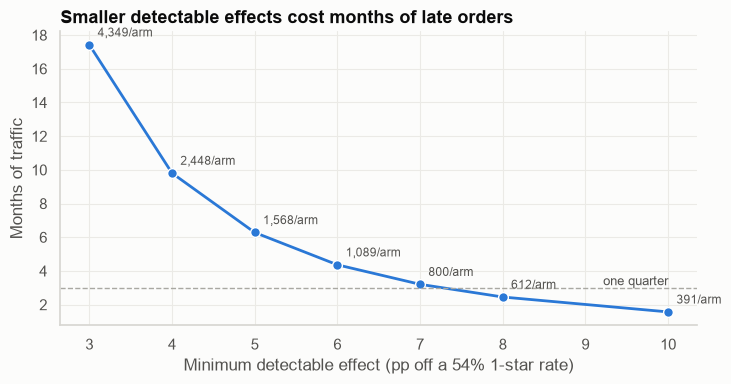

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(table["mde_pp"], table["months"], color=BLUE, marker="o", markersize=7, markeredgecolor="white")
for _, r in table.iterrows():
    ax.annotate(f"{int(r['n_per_arm']):,}/arm", (r["mde_pp"], r["months"]), textcoords="offset points",
                xytext=(6, 6), fontsize=8.5, color=INK_2)
ax.axhline(3, color=GREY, lw=1, ls="--")
ax.text(table["mde_pp"].max(), 3.15, "one quarter", ha="right", fontsize=9, color=INK_2)
ax.set(title="Smaller detectable effects cost months of late orders",
       xlabel="Minimum detectable effect (pp off a 54% 1-star rate)", ylabel="Months of traffic")
plt.tight_layout()
plt.show()

## 3. Recommendation

Pick the smallest MDE that finishes within one quarter (≤ 3 months at the mean run-rate), so the result
lands inside a planning cycle and survives a slow month or two.

In [7]:
rec = table[table["months"] <= 3].iloc[0]
print(f"Recommended: MDE {rec['mde_pp']:.0f} pp (54% -> {rec['p_treatment']:.0%}, "
      f"{rec['relative_mde']:.0%} relative), {int(rec['n_per_arm']):,} late reviewed orders per arm, "
      f"{int(rec['n_total']):,} total, ≈ {rec['months']:.1f} months")
row5 = table.set_index("mde_pp").loc[5]
print(f"For reference, 5 pp needs {int(row5['n_per_arm']):,}/arm ≈ {row5['months']:.1f} months")
N_REC = int(rec["n_per_arm"])

Recommended: MDE 8 pp (54% -> 46%, 15% relative), 612 late reviewed orders per arm, 1,224 total, ≈ 2.5 months
For reference, 5 pp needs 1,568/arm ≈ 6.3 months


**Why not 5 pp?** It needs ~6 months of late orders, long enough for seasonality, carrier changes and
novelty to blur the result. A ~7–8 pp effect (≈ 15% relative) is also the size that would matter commercially:
the voucher has a cost, and a smaller lift is unlikely to pay for it. Pre-register the MDE, the stopping
date and the decision rule (ship if the primary metric improves at p < 0.05 and no guardrail degrades).

## 4. A/A simulation: is the false-positive rate really 5%?

1,000 experiments where both arms share the same true 1-star rate (54%) at the recommended sample size,
each analysed with the same two-sided z-test. Under the null, p-values should be uniform and about 5% of
them should fall below 0.05.

A/A false-positive rate: 4.7% (expected 5.0% ± 1.4%)


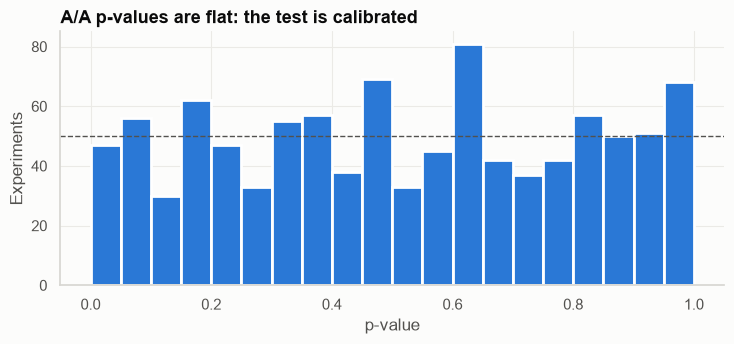

In [8]:
pvals = simulate_aa(P0, N_REC, n_sims=1_000, alpha=ALPHA, seed=SEED)
fpr = (pvals < ALPHA).mean()
se = np.sqrt(ALPHA * (1 - ALPHA) / len(pvals))
print(f"A/A false-positive rate: {fpr:.1%} (expected 5.0% ± {1.96 * se:.1%})")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(pvals, bins=20, range=(0, 1), color=BLUE, edgecolor="white", linewidth=2)
ax.axhline(len(pvals) / 20, color=INK_2, lw=1, ls="--")
ax.set(title="A/A p-values are flat: the test is calibrated", xlabel="p-value", ylabel="Experiments")
plt.tight_layout()
plt.show()

And the other side: simulated with a true effect equal to the MDE, the test should detect it ~80% of the time.

In [9]:
rng = np.random.default_rng(SEED)
p_t = rec["p_treatment"]
a = rng.binomial(N_REC, P0, 1_000)
b = rng.binomial(N_REC, p_t, 1_000)
pool = (a + b) / (2 * N_REC)
z = (a - b) / (N_REC * np.sqrt(pool * (1 - pool) * 2 / N_REC))
print(f"Simulated power at {P0:.0%} vs {p_t:.0%}, n = {N_REC:,}/arm: {(2 * norm.sf(np.abs(z)) < ALPHA).mean():.1%}")

Simulated power at 54% vs 46%, n = 612/arm: 79.2%


## 5. Sample-ratio mismatch (SRM)

With a 50/50 split the two arms should hold about the same number of analysable (late, reviewed) orders. A
chi-square goodness-of-fit test on the arm counts flags a mismatch; check it **before** reading the metric.
A significant SRM (commonly p < 0.001) means the assignment or logging is broken (e.g. the notification
changes whether a review gets left, or the delay model flags differently by arm) and the result can't be
trusted. Here the risk is real: the treatment could itself change who leaves a review, so also compare the
review-submission rate between arms.

Run the SRM check on **all assigned units** (flagged orders / customers), not only on the late, reviewed
orders: the same imbalance is obvious on 10,000 assigned orders but invisible on ~1,200 analysed ones.

In [10]:
examples = {
    "assigned, healthy 50/50": (5_000, 5_000),
    "assigned, 52/48": (5_200, 4_800),
    "late reviewed, 52/48": (636, 588),
}
for label, (na, nb) in examples.items():
    print(f"{label:<26} arms {na:,} / {nb:,}: SRM p = {srm_pvalue(na, nb):.2g}")

assigned, healthy 50/50    arms 5,000 / 5,000: SRM p = 1
assigned, 52/48            arms 5,200 / 4,800: SRM p = 6.3e-05
late reviewed, 52/48       arms 636 / 588: SRM p = 0.17


## 6. Peeking

Checking the p-value repeatedly and stopping at the first "significant" look inflates the false-positive
rate far above 5%. The simulation below runs A/A tests with 10 interim looks (e.g. weekly) and stops at the
first p < 0.05. Fix: commit to the sample size and look once, or use a sequential design (alpha spending such
as O'Brien–Fleming) if early stopping is needed.

In [11]:
looks = 10
sims = 2_000
rng = np.random.default_rng(SEED)
per_look = int(np.ceil(N_REC / looks))
a = rng.binomial(per_look, P0, size=(sims, looks)).cumsum(axis=1)
b = rng.binomial(per_look, P0, size=(sims, looks)).cumsum(axis=1)
n = per_look * np.arange(1, looks + 1)
pool = (a + b) / (2 * n)
z = (a - b) / (n * np.sqrt(pool * (1 - pool) * 2 / n))
sig = 2 * norm.sf(np.abs(z)) < ALPHA
print(f"False-positive rate, single look at the end: {sig[:, -1].mean():.1%}")
print(f"False-positive rate, stop at first significant of {looks} looks: {sig.any(axis=1).mean():.1%}")

False-positive rate, single look at the end: 5.1%
False-positive rate, stop at first significant of 10 looks: 20.1%


## Summary

In [12]:
pd.Series({
    "baseline 1-star rate, late orders": f"{overall:.1%} (planning value {P0:.0%})",
    "late reviewed orders / month (Jan-Aug 2018)": f"{runrate:,.0f}",
    "n per arm, 5 pp MDE (54% -> 49%)": f"{N_5PP:,} ≈ {2 * N_5PP / runrate:.1f} months",
    "recommended MDE": f"{rec['mde_pp']:.0f} pp -> {N_REC:,}/arm ≈ {rec['months']:.1f} months",
    "A/A false-positive rate": f"{fpr:.1%}",
    "peeking (10 looks) false-positive rate": f"{sig.any(axis=1).mean():.1%}",
}, name="value").to_frame()

,value
"baseline 1-star rate, late orders",53.8% (planning value 54%)
late reviewed orders / month (Jan-Aug 2018),499
"n per arm, 5 pp MDE (54% -> 49%)","1,568 ≈ 6.3 months"
recommended MDE,8 pp -> 612/arm ≈ 2.5 months
A/A false-positive rate,4.7%
peeking (10 looks) false-positive rate,20.1%
